## 1. Imports

In [58]:
import boto3
import os
from dotenv import load_dotenv
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from typing import Tuple

import logging



In [17]:
load_dotenv

os.getenv('AWS_ACCESS_KEY_ID') is not None

True

In [18]:
logger = logging.getLogger(__name__)
logger.level = logging.INFO
handler = logging.StreamHandler()
logger.addHandler(handler)

## Data Set loading

In [24]:
LOCAL_DATA_DIR = Path('../../data/module3')
FILE_NAME = 'feature_frame.csv'
local_path = LOCAL_DATA_DIR/FILE_NAME


In [25]:
df_original= pd.read_csv(local_path)
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880549 entries, 0 to 2880548
Data columns (total 27 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   variant_id                        int64  
 1   product_type                      object 
 2   order_id                          int64  
 3   user_id                           int64  
 4   created_at                        object 
 5   order_date                        object 
 6   user_order_seq                    int64  
 7   outcome                           float64
 8   ordered_before                    float64
 9   abandoned_before                  float64
 10  active_snoozed                    float64
 11  set_as_regular                    float64
 12  normalised_price                  float64
 13  discount_pct                      float64
 14  vendor                            object 
 15  global_popularity                 float64
 16  count_adults                      fl

In [26]:
df_original.head()


,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [27]:
df = df_original.copy()


## 3. Data Set cleaning

In [28]:
info_cols = ["variant_id", "order_id", "user_id", "created_at", "order_date" ]
target_cols = "outcome"
feature_cols = [col for col in df.columns if col not in info_cols + [target_cols]]

categorical_cols = ["vendor", "product_type"]
binary_cols = ["ordered_before","active_snoozed", "abandoned_before","set_as_regular"]
numerical_cols = [col for col in feature_cols if col not in categorical_cols + binary_cols]


In [34]:
def create_wanted_df(df:pd.DataFrame, min_products: int = 5) -> pd.DataFrame:
    """we want only orders with more than five products"""
    order_size = df.groupby("order_id")["outcome"].sum()
    orders_wanted = order_size[order_size >= min_products].index
    return df.loc[lambda x: x.order_id.isin(orders_wanted)]


def format_date_cols(df: pd.DataFrame) -> pd.DataFrame:
    return(
        df
        .assign(created_at = lambda x: pd.to_datetime(x.created_at))
        .assign(order_date = lambda x: pd.to_datetime(x.order_date).dt.date)

    )

df_selected = (
    df.pipe(create_wanted_df)
    .pipe(format_date_cols)
)

In [35]:
df.order_id.nunique() > df_selected.order_id.nunique()

True

In [36]:
df_selected.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
5,33826472919172,ricepastapulses,2808434524292,3479090790532,2020-10-06 10:50:23,2020-10-06,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [37]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2163953 entries, 0 to 2880547
Data columns (total 27 columns):
 #   Column                            Dtype         
---  ------                            -----         
 0   variant_id                        int64         
 1   product_type                      object        
 2   order_id                          int64         
 3   user_id                           int64         
 4   created_at                        datetime64[ns]
 5   order_date                        object        
 6   user_order_seq                    int64         
 7   outcome                           float64       
 8   ordered_before                    float64       
 9   abandoned_before                  float64       
 10  active_snoozed                    float64       
 11  set_as_regular                    float64       
 12  normalised_price                  float64       
 13  discount_pct                      float64       
 14  vendor                 

In [38]:
df_selected = df_selected.sample(n=100000, random_state = 42)

For memory optimization purposes, we will reduce the data set length from 2M rows to 100k, as they should be enough to get a good training fit, while getting good speed of processing.

We won't encode categorical variables yet, as we will try to follow an incremental training on the model, to determine if its performance increases in a reasonable way when adding the categorical variables so that it is worth it to use them and process them.

## Model selection and evaluation

In [63]:
from sklearn.metrics import precision_recall_curve,auc
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

### Data split and scale

As commented in the same seccion of the exploration for linear models, columns `variant_id`, `user_id` and `order_id` will be removed, as well as the categorical variables (that may later be aded if we find that they improve the model).

As in the previous exploration, in order to avoid the data leakage we will perform a time-based data split.

In [40]:
daily_orders = df_selected.groupby('order_date').order_id.nunique()

In [41]:
daily_orders.head()

order_date
2020-10-05     3
2020-10-06     7
2020-10-07     6
2020-10-08    12
2020-10-09     4
Name: order_id, dtype: int64

Text(0.5, 1.0, 'Daily_orders')

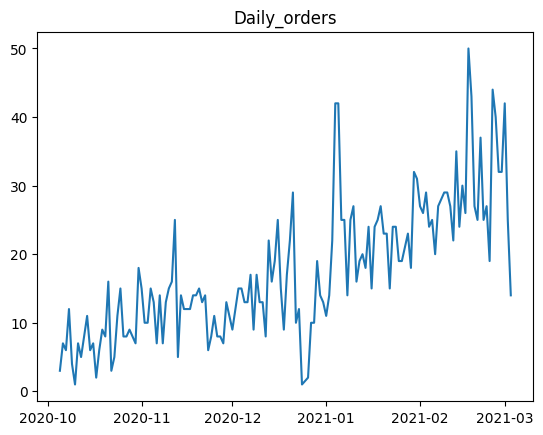

In [44]:
plt.plot(daily_orders, label = "daily_orders")
plt.title("Daily_orders")

As showed in previous explorations, the purchase behaviour changes over time, giving us another reason apart from the temporal nature of the data to perform a time split, as we can not assume that the puchase behaviour in the future will remain the same, and the model must be subjected to that uncertainity too

[]

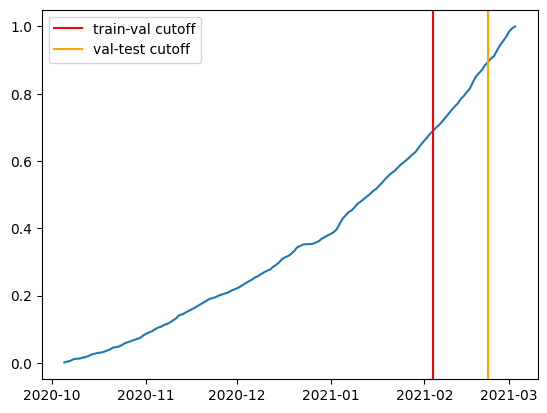

In [54]:
cumsum_daily_orders = daily_orders.cumsum()/daily_orders.sum()

train_cutoff = cumsum_daily_orders[cumsum_daily_orders<=0.7].idxmax()
val_cutoff = cumsum_daily_orders[cumsum_daily_orders<=0.9].idxmax()

df_train = df_selected[df_selected.order_date <= train_cutoff]

df_val = df_selected[
    (df_selected.order_date > train_cutoff) &
    (df_selected.order_date <= val_cutoff)
    ]

df_test = df_selected[df_selected.order_date > val_cutoff]

plt.plot(cumsum_daily_orders)
plt.axvline(train_cutoff, color = 'red', label = 'train-val cutoff')
plt.axvline(val_cutoff, color = 'orange', label = 'val-test cutoff')
plt.legend()
plt.plot()


### BASELINE

In order to develop a non-linear model, we have to compare against a more simple model, to see if the improvement in performance justifys the implementation of a more complex model

In this case, we will use the best model obtained from the linear models exploration phase.


In [60]:
import matplotlib
def plot_metrics(
        model_name: str,
        y_pred: pd.Series,
        y_test: pd.Series,
        target_precision: float = 0.05,
        figure: Tuple[matplotlib.figure.Figure, np.array] = None
):
    precision, recall,_ = precision_recall_curve(y_test,y_pred)
    pr_auc = auc(recall, precision)

    fpr, tpr,_ = roc_curve(y_test,y_pred)
    roc_auc = roc_auc_score(y_test,y_pred)
    
    if figure is None:
        fig, ax = plt.subplots(1,2,figsize = (14,7))
    else:
        fig,ax = figure

    ax[0].plot(recall,precision,label = f"{model_name}; AUC: {pr_auc:.2f}") 
    ax[0].set_xlabel('recall')
    ax[0].set_ylabel('precision')
    ax[0].set_title('Precision-recall curve')
    ax[0].legend()

    ax[1].plot(fpr,tpr,label = f"{model_name}; AUC: {roc_auc:.2f}") 
    ax[1].set_xlabel('False positive rate')
    ax[1].set_ylabel('True positive rate')
    ax[1].set_title('ROC curve')
    ax[1].legend()





In [68]:
def feature_split(
        df: pd.DataFrame, target_col: str
) -> Tuple[pd.DataFrame, pd.Series]:
    return df.drop(columns = target_col), df[target_col]

X_train, y_train = feature_split(df_train,target_cols)
X_val, y_val = feature_split(df_val,target_cols)
X_test, y_test = feature_split(df_test,target_cols)

training_cols = numerical_cols + binary_cols

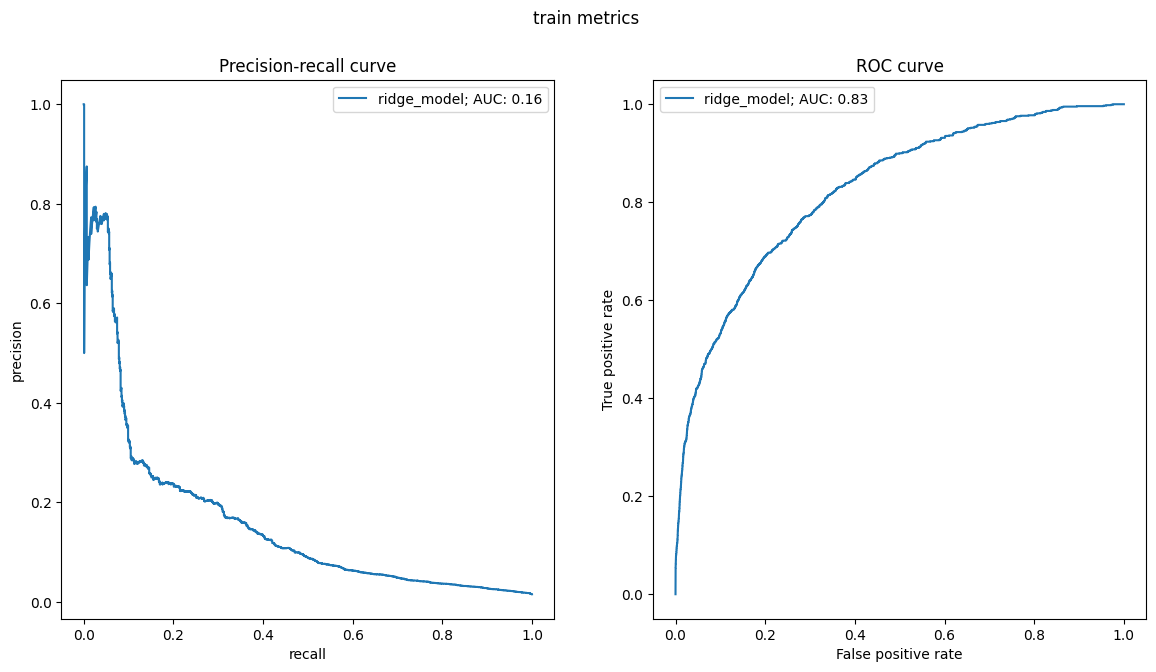

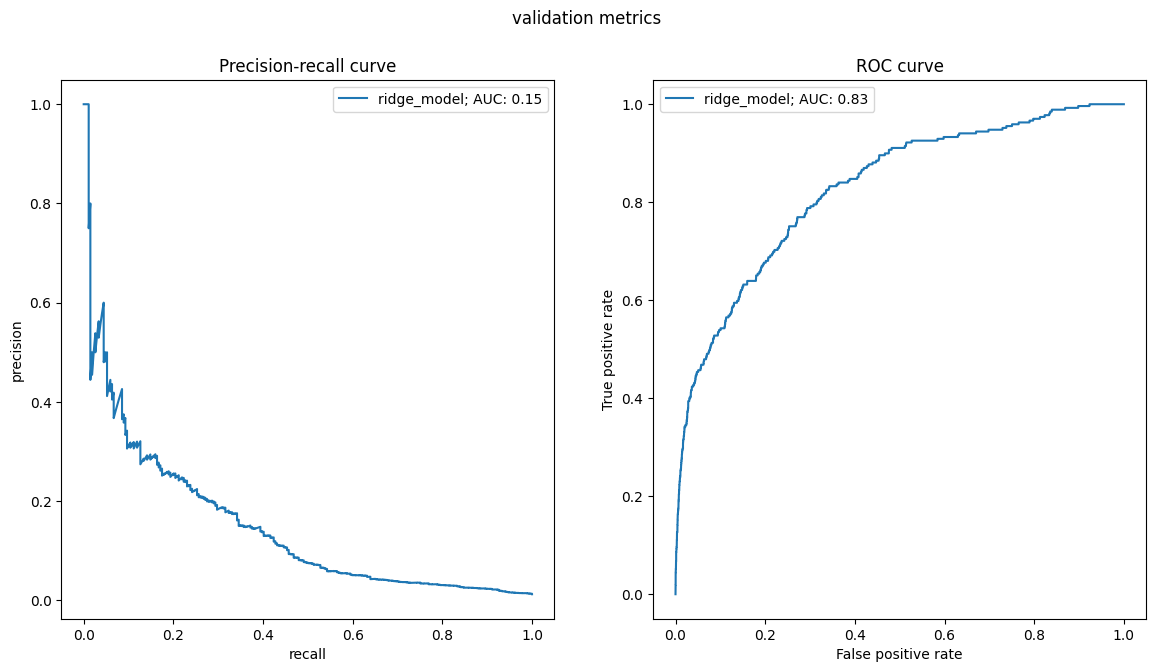

In [72]:
fig1, ax1 = plt.subplots(1,2,figsize = (14,7))
fig1.suptitle('train metrics')

fig2, ax2 = plt.subplots(1,2,figsize = (14,7))
fig2.suptitle('validation metrics')

lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty='l2',C = 1e-4)
    )

lr.fit(X_train[training_cols],y_train)
y_pred = lr.predict_proba(X_train[training_cols])[:,1]
plot_metrics('ridge_model',y_pred,y_train, figure=(fig1,ax1))

y_pred = lr.predict_proba(X_val[training_cols])[:,1]
plot_metrics('ridge_model',y_pred,y_val, figure=(fig2,ax2))






## Model training

In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score

### Decision tree

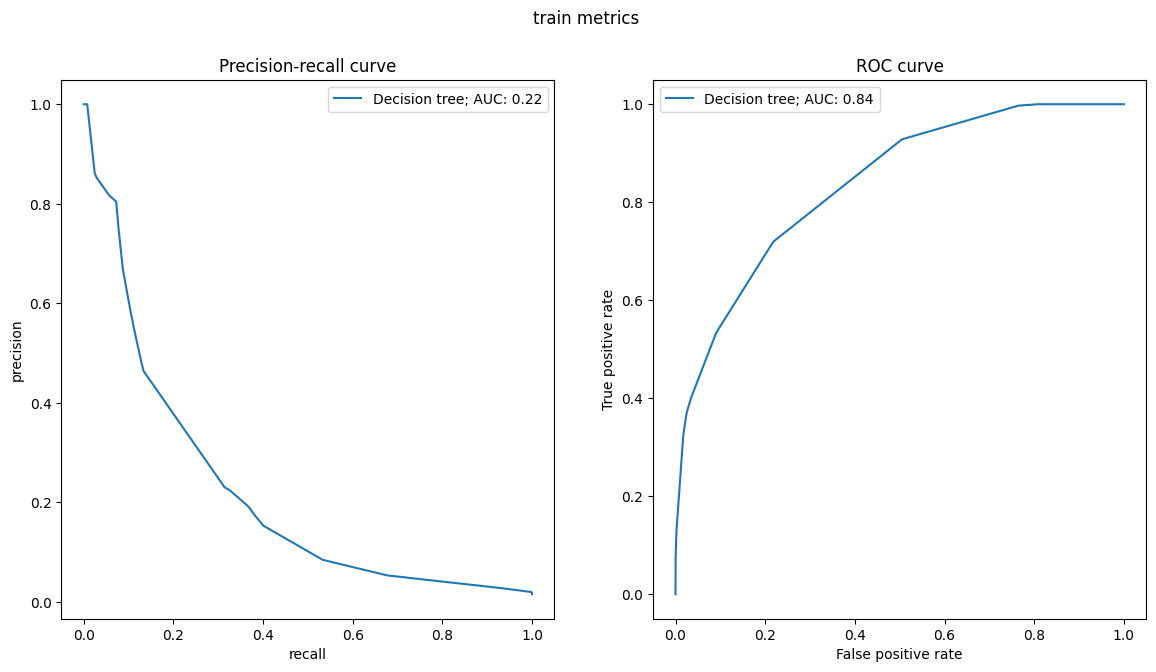

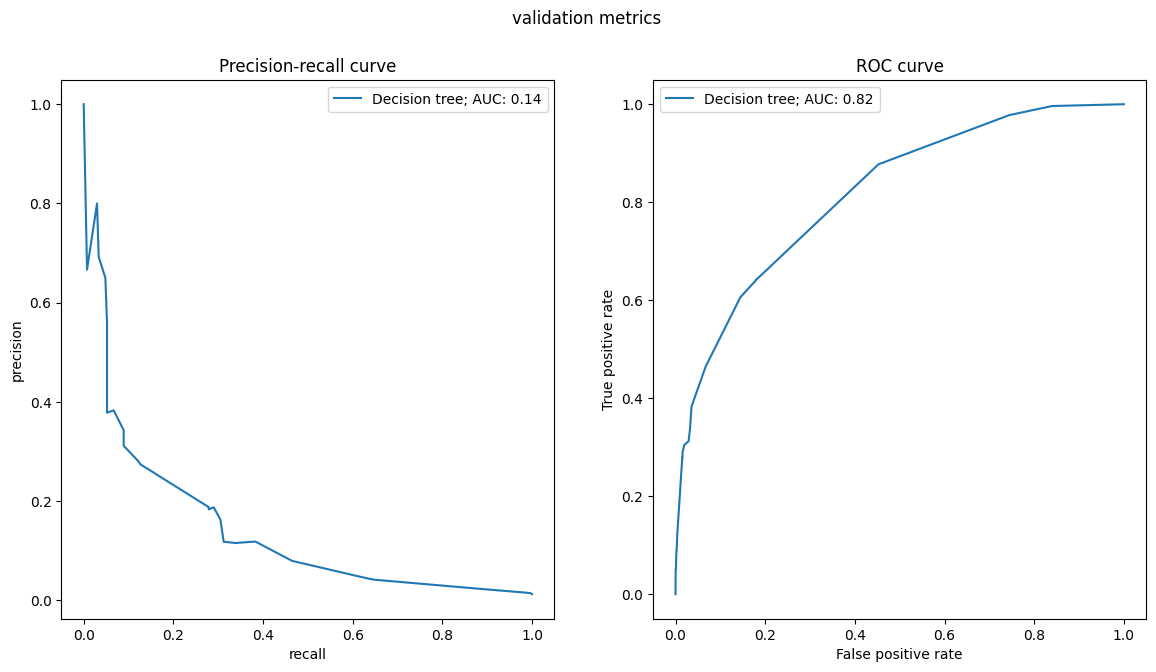

In [79]:
fig1, ax1 = plt.subplots(1,2,figsize = (14,7))
fig1.suptitle('train metrics')

fig2, ax2 = plt.subplots(1,2,figsize = (14,7))
fig2.suptitle('validation metrics')

param_grid = {
    "max_depth": [3,5,7,10,15,None],
    "min_samples_split": [2,5,10,20,50],
    "min_samples_leaf": [1,2,5,10,20],
    "criterion": ["gini","entropy"]
}

tree = DecisionTreeClassifier(random_state=42)
tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    tree,
    param_grid=param_grid,
    cv=tscv,
    scoring="average_precision",
    n_jobs=-1
    )

grid.fit(X_train[training_cols], y_train)
best_tree = grid.best_estimator_
y_pred = best_tree.predict_proba(X_train[training_cols])[:,1]
plot_metrics("Decision tree", y_pred,y_train, figure=(fig1,ax1))

y_pred = best_tree.predict_proba(X_val[training_cols])[:,1]
plot_metrics("Decision tree", y_pred,y_val,figure=(fig2,ax2))







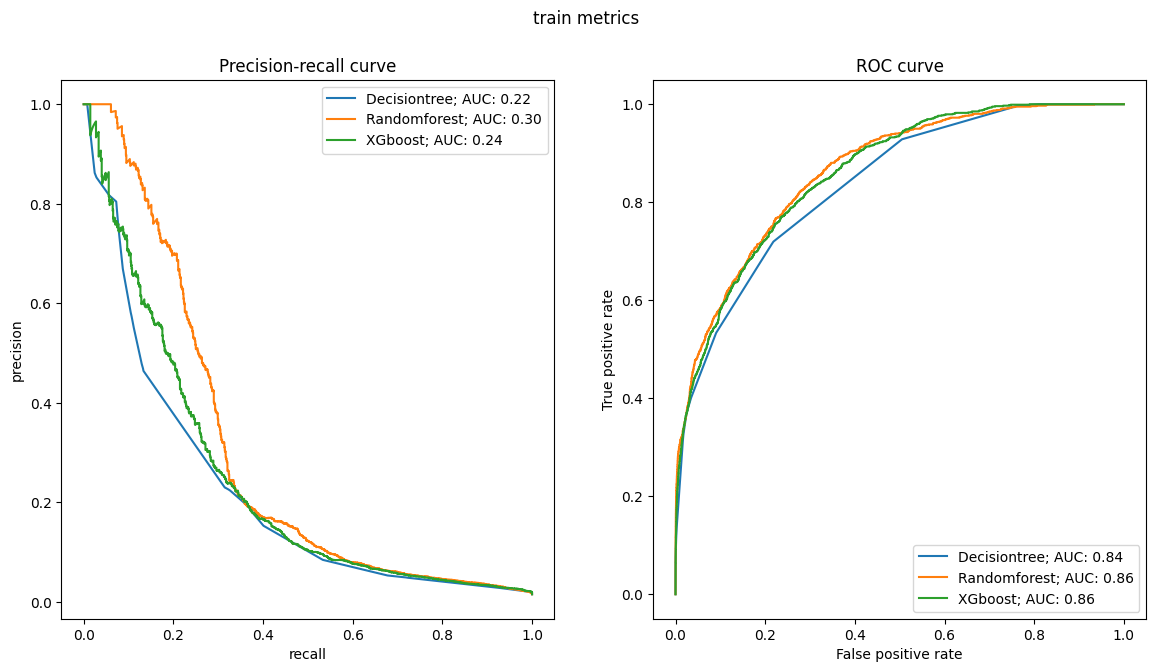

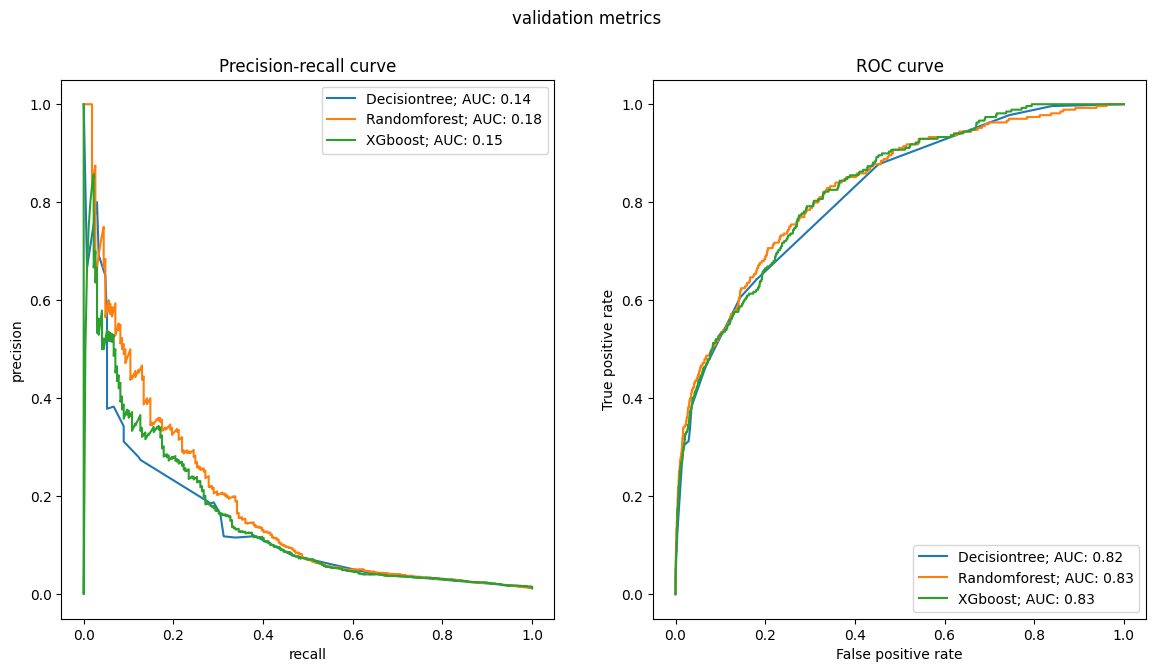

In [ ]:
fig1, ax1 = plt.subplots(1,2,figsize = (14,7))
fig1.suptitle('train metrics')

fig2, ax2 = plt.subplots(1,2,figsize = (14,7))
fig2.suptitle('validation metrics')

param_grids = {
    'Decisiontree':{
    "max_depth": [3,5,7,10,15,None],
    "min_samples_split": [2,5,10,20,50],
    "min_samples_leaf": [1,2,5,10,20],
    "criterion": ["gini","entropy"]
    },

    'Randomforest': {
        "n_estimators": [100,200],
        "max_depth": [1,3,5,7],
        "min_samples_leaf": [1,2,5,10,20],
        "max_features": ["sqrt","log2"]
    },

    'XGboost': {
        "n_estimators": [100,200],
        "max_depth": [1,3,5,7],
        "learning_rate": [0.01,0.05,0.1],
        "subsample": [0.6,0.8,1]
    }
}

models = {
    'Decisiontree': DecisionTreeClassifier(random_state=42),
    'Randomforest': RandomForestClassifier(random_state=42),
    'XGboost': XGBClassifier(random_state=42, eval_metric="logloss")
    }

tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name,model in models.items():

    grid = GridSearchCV(
        model,
        param_grid = param_grids[name],
        cv = tscv,
        scoring='average_precision',
        n_jobs=-1
    )

    grid.fit(X_train[training_cols],y_train)
    results[name] = grid.best_estimator_

    best_model = grid.best_estimator_

    y_pred = best_model.predict_proba(X_train[training_cols])[:,1]
    plot_metrics(name,y_pred,y_train,figure=(fig1,ax1))

    y_pred = best_model.predict_proba(X_val[training_cols])[:,1]
    plot_metrics(name,y_pred,y_val,figure = (fig2,ax2))








In [84]:
best_model = results['Randomforest']

As we observe in the graphics, based on the ROC scores and the PR score, tha RandomForest model is the one which performs better, although the difference is not remarkable.

When comparing against the baseline, it outperforms it, but only by 0.04 points in validation metrics. With that data gathered, we should ask the business if it is enough for them as to implement this new model

We will now repeat the training for the best model, but adding the categorical columns to see if it increments the performance 

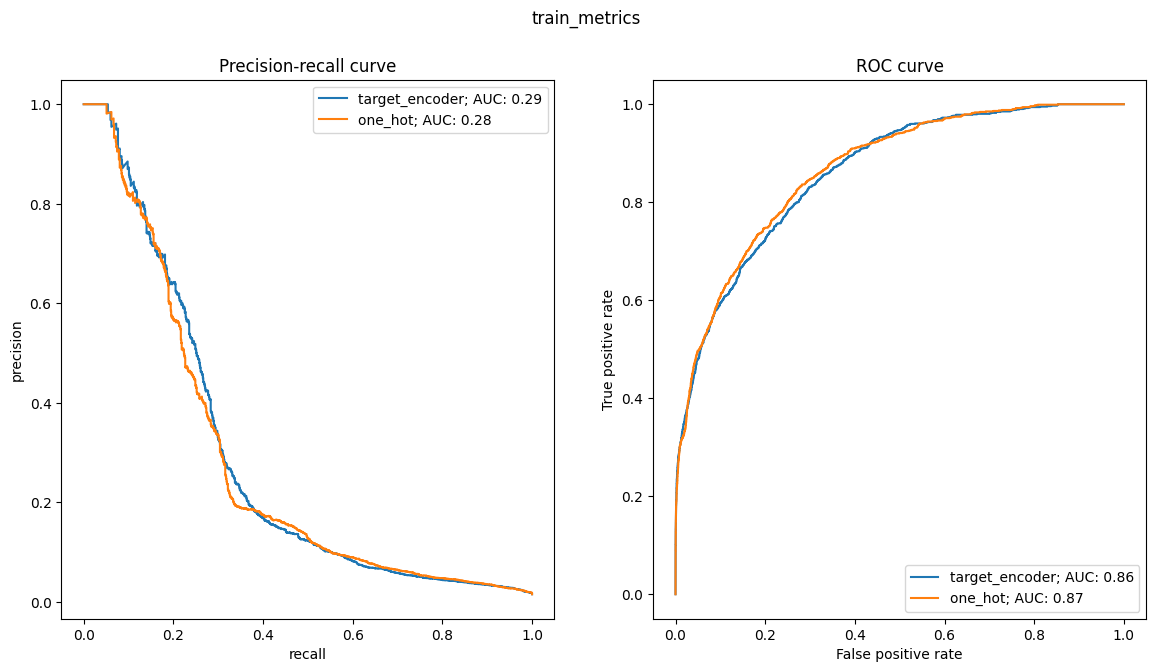

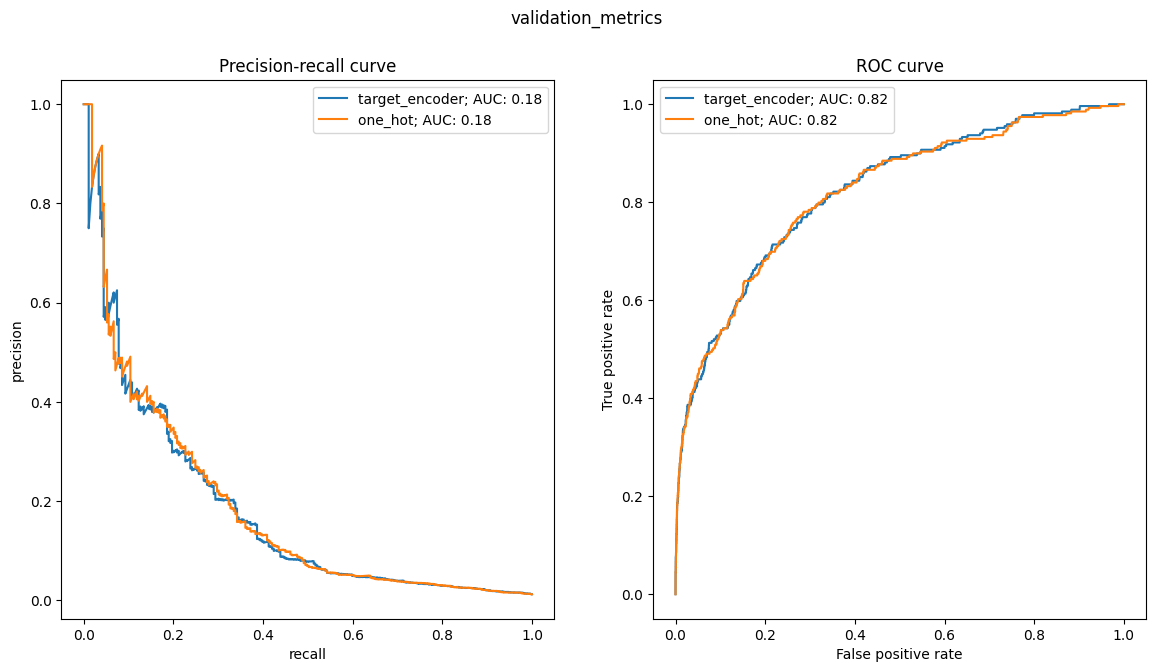

In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder

categorical_preprocessors = [
    ("target_encoder",TargetEncoder(target_type="binary")),
    ("one_hot",OneHotEncoder(handle_unknown="ignore", max_categories=20))
]

fig1,ax1 = plt.subplots(1,2,figsize = (14,7))
fig1.suptitle("train_metrics")

fig2,ax2 = plt.subplots(1,2,figsize = (14,7))
fig2.suptitle("validation_metrics")

extended_cols = training_cols + categorical_cols

for name, encoder in categorical_preprocessors:
    preprocessor = ColumnTransformer(
        [
            ("numerical",'passthrough',training_cols),
            ("categorical",encoder,categorical_cols)
        ]
    )
    lr = make_pipeline(
    preprocessor,
    RandomForestClassifier(**results['Randomforest'].get_params())
    )

    lr.fit(X_train[extended_cols],y_train)
    y_pred = lr.predict_proba(X_train[extended_cols])[:,1]
    plot_metrics(name,y_pred,y_train,figure=(fig1,ax1))

    y_pred = lr.predict_proba(X_val[extended_cols])[:,1]
    plot_metrics(name,y_pred,y_val,figure = (fig2,ax2))




The graphics show that the performance of the model is not affected by the addition of the categorical columns, so there is no reason to implement them in the training pipeline.

## Final Test

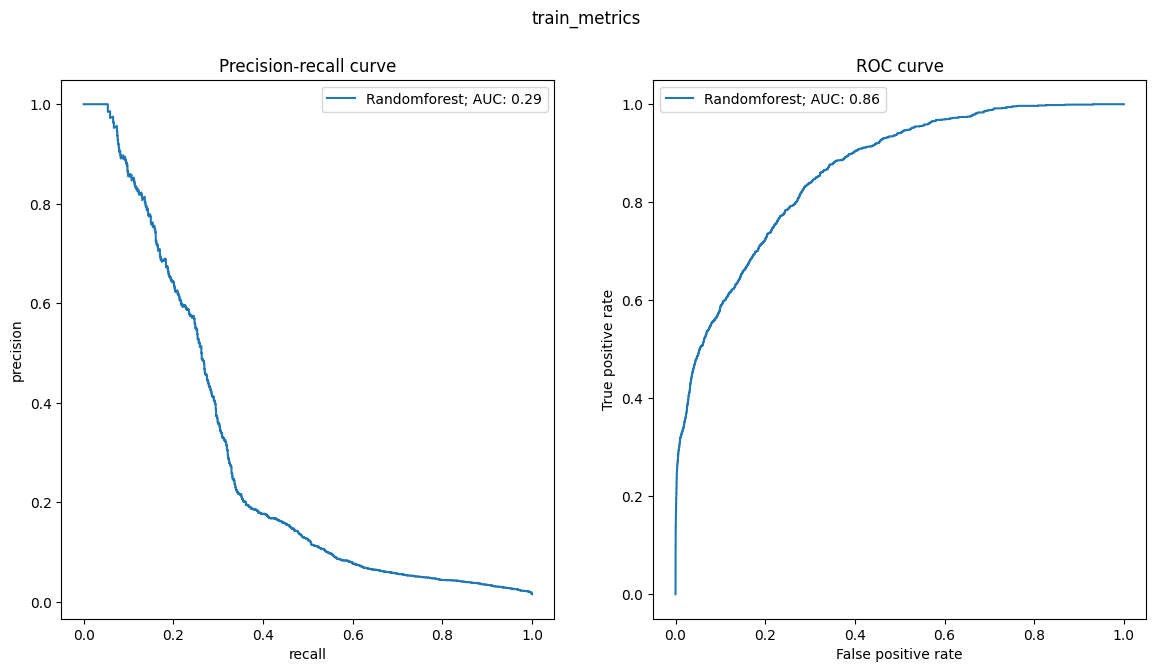

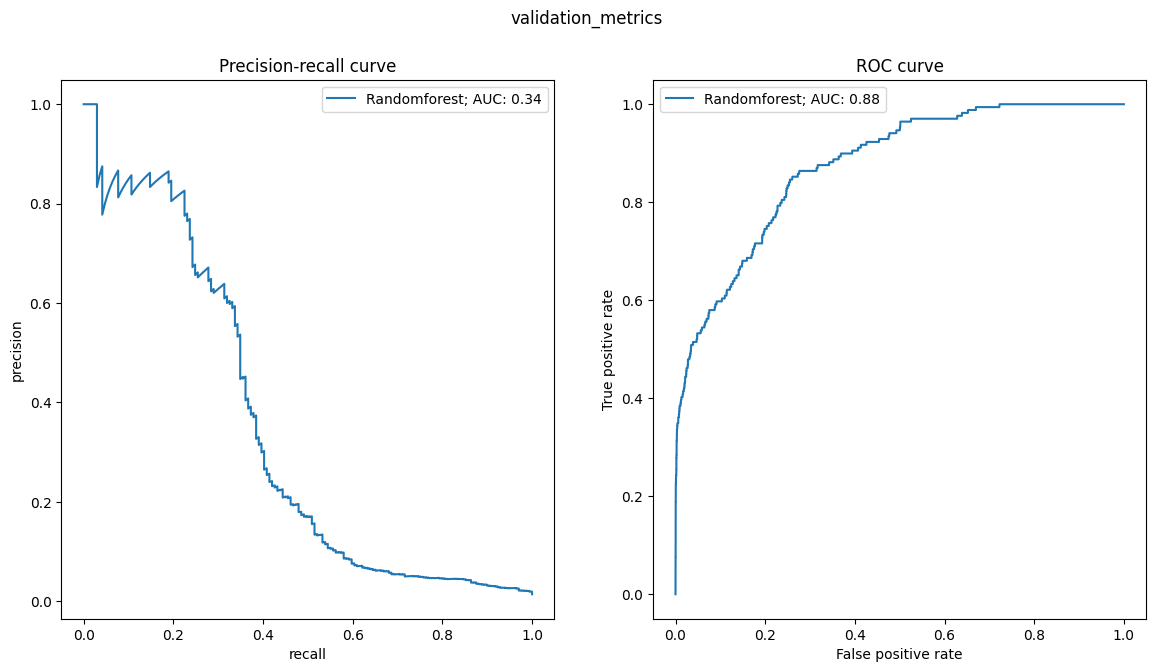

In [89]:
X_train_val = pd.concat([X_train,X_test])
y_train_val = pd.concat([y_train,y_test])

fig1,ax1 = plt.subplots(1,2,figsize = (14,7))
fig1.suptitle("train_metrics")

fig2,ax2 = plt.subplots(1,2,figsize = (14,7))
fig2.suptitle("validation_metrics")


best_model = RandomForestClassifier(**results['Randomforest'].get_params())
best_model.fit(X_train_val[training_cols],y_train_val)

y_pred = best_model.predict_proba(X_train_val[training_cols])[:,1]
plot_metrics('Randomforest',y_pred,y_train_val,figure=(fig1,ax1))

y_pred = best_model.predict_proba(X_test[training_cols])[:,1]
plot_metrics("Randomforest",y_pred,y_test,figure=(fig2,ax2))